# 0. Predições Out-of-Fold (OOF) dos modelos base

### Para evitar overfitting e vazamento de dados (data leakage), o meta-modelo não pode ser treinado com previsões feitas em dados que os modelos base já viram durante o treino. 
Usamos a Validação Cruzada (StratifiedKFold) para gerar previsões Out-of-Fold (OOF), ou seja, para cada dobra (fold), o modelo prevê apenas os dados que ficaram de fora daquele treinamento.

In [7]:
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Caminho absoluto/relativo corrigido para a raiz do projeto
caminhos_possiveis = [
    '../../data/processed/',
    '../data/processed/',
    './data/processed/'
]

X_tr_data, X_te_data, y_train, y_test = None, None, None, None

for pasta in caminhos_possiveis:
    p_xtr = os.path.join(pasta, 'X_train_vec.pkl')
    if os.path.exists(p_xtr):
        try:
            X_tr_data = joblib.load(p_xtr)
            X_te_data = joblib.load(os.path.join(pasta, 'X_test_vec.pkl'))
            y_train = joblib.load(os.path.join(pasta, 'y_train.pkl'))
            y_test = joblib.load(os.path.join(pasta, 'y_test.pkl'))
            print(f"✅ Dados carregados com sucesso da pasta: '{pasta}'")
            break
        except Exception:
            continue

if X_tr_data is None:
    raise ValueError(
        "❌ As matrizes de treino/teste não foram encontradas. Certifique-se de executar e salvar os arquivos .pkl no notebook anterior."
    )

✅ Dados carregados com sucesso da pasta: '../../data/processed/'


### 2. Geração de Predições Out-of-Fold (OOF) dos Modelos Base
Utilizamos a Validação Cruzada Estratificada (`StratifiedKFold`) para treinar os modelos base (Regressão Logística, SVM Linear e Random Forest) em diferentes dobras. Isso gera predições desvies e confiáveis em cima do conjunto de treino, evitando overfitting no meta-modelo.

In [8]:
# Configurando a validação cruzada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_base = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Linear SVM': SVC(kernel='linear', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

oof_preds_train = pd.DataFrame(index=y_train.index)
preds_test_dict = {}

for nome, modelo in modelos_base.items():
    print(f"Treinando e avaliando o modelo base: {nome}...")
    
    oof_preds = np.zeros(X_tr_data.shape[0])
    test_preds_folds = np.zeros(X_te_data.shape[0])
    
    for train_idx, val_idx in skf.split(X_tr_data, y_train):
        X_tr, X_val = X_tr_data[train_idx], X_tr_data[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        modelo.fit(X_tr, y_tr)
        oof_preds[val_idx] = modelo.predict_proba(X_val)[:, 1]
        test_preds_folds += modelo.predict_proba(X_te_data)[:, 1] / skf.n_splits
        
    oof_preds_train[nome] = oof_preds
    preds_test_dict[nome] = test_preds_folds

print("✨ Predições OOF geradas com sucesso para todos os modelos base!")

Treinando e avaliando o modelo base: Logistic Regression...
Treinando e avaliando o modelo base: Linear SVM...


c:\Users\LAISA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\LAISA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\LAISA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\LAISA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\

Treinando e avaliando o modelo base: Random Forest...
✨ Predições OOF geradas com sucesso para todos os modelos base!


### 3. Construção das Entradas do Meta-Modelo (Stacking Features)
Transformamos as predições geradas na etapa anterior em novos DataFrames. As predições OOF formam as features de treino do meta-modelo, enquanto as médias das predições de teste formam as features de teste do meta-modelo.

In [9]:
X_meta_train = oof_preds_train.copy()
X_meta_test = pd.DataFrame(preds_test_dict, index=range(X_te_data.shape[0]))

print(f"Dimensões das features de treino do Stacking: {X_meta_train.shape}")
print(f"Dimensões das features de teste do Stacking: {X_meta_test.shape}")

Dimensões das features de treino do Stacking: (9521, 3)
Dimensões das features de teste do Stacking: (2381, 3)


### 4. Treinamento do Meta-Modelo
Instanciamos e treinamos o meta-modelo (uma Regressão Logística secundária) utilizando como entrada as predições feitas pelos modelos base. O meta-modelo aprende a ponderar qual modelo base é mais confiável para tomar a decisão final.

In [10]:
meta_model = LogisticRegression(random_state=42)
meta_model.fit(X_meta_train, y_train)

print("Meta-modelo treinado com sucesso!")

Meta-modelo treinado com sucesso!


### 5. Geração da Previsão Final do Ensemble e Métricas
Aplicamos o meta-modelo treinado sobre as features de teste e avaliamos a performance final do nosso sistema de Ensemble utilizando métricas como Acurácia, ROC-AUC e o Relatório de Classificação completo.

In [11]:
y_pred_proba_final = meta_model.predict_proba(X_meta_test)[:, 1]
y_pred_final = meta_model.predict(X_meta_test)

acuracia_final = accuracy_score(y_test, y_pred_final)
roc_auc_final = roc_auc_score(y_test, y_pred_proba_final)

print(f"\n🏆 Resultados Finais do Ensemble (Stacking):")
print(f" - Acurácia Final: {acuracia_final:.4f}")
print(f" - ROC-AUC Final: {roc_auc_final:.4f}")
print("\nRelatório de Classificação Detalhado:")
print(classification_report(y_test, y_pred_final))


🏆 Resultados Finais do Ensemble (Stacking):
 - Acurácia Final: 0.9765
 - ROC-AUC Final: 0.9964

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1191
           1       0.98      0.97      0.98      1190

    accuracy                           0.98      2381
   macro avg       0.98      0.98      0.98      2381
weighted avg       0.98      0.98      0.98      2381



### 6. Visualização Final: Comparação de Desempenho (Modelos Base vs. Ensemble)
Geramos um gráfico de barras comparando a **Acurácia** e o **ROC-AUC** de cada modelo individual (Regressão Logística, SVM Linear e Random Forest) em contraponto ao modelo final de Stacking.

c:\Users\LAISA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\LAISA\AppData\Local\Temp\ipykernel_14012\1101403677.py:41: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LAISA\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


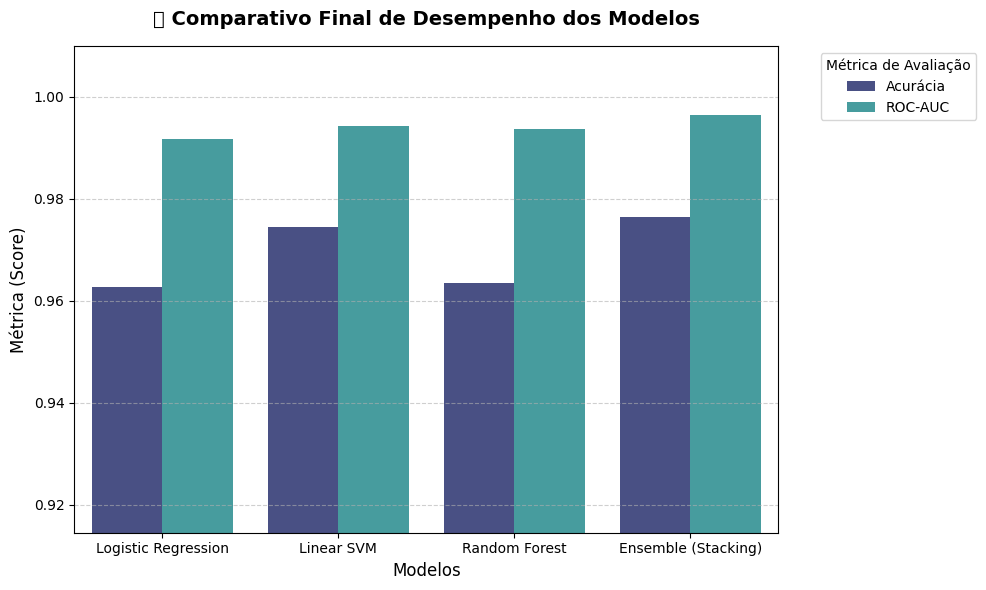

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_auc_score

# Estruturando os resultados para o gráfico
resultados = {
    'Modelo': [],
    'Acurácia': [],
    'ROC-AUC': []
}

# Avaliando os modelos base individualmente no conjunto de teste
for nome, modelo in modelos_base.items():
    modelo.fit(X_tr_data, y_train)
    y_pred_base = modelo.predict(X_te_data)
    y_proba_base = modelo.predict_proba(X_te_data)[:, 1]
    
    resultados['Modelo'].append(nome)
    resultados['Acurácia'].append(accuracy_score(y_test, y_pred_base))
    resultados['ROC-AUC'].append(roc_auc_score(y_test, y_proba_base))

# Adicionando os resultados do Stacking Ensemble
resultados['Modelo'].append('Ensemble (Stacking)')
resultados['Acurácia'].append(acuracia_final)
resultados['ROC-AUC'].append(roc_auc_final)

df_resultados = pd.DataFrame(resultados)

# Configuração do Gráfico
plt.figure(figsize=(10, 6))
df_melted = df_resultados.melt(id_vars='Modelo', value_vars=['Acurácia', 'ROC-AUC'], var_name='Métrica', value_name='Valor')

sns.barplot(data=df_melted, x='Modelo', y='Valor', hue='Métrica', palette='mako')

plt.title('📊 Comparativo Final de Desempenho dos Modelos', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Modelos', fontsize=12)
plt.ylabel('Métrica (Score)', fontsize=12)
plt.ylim(min(df_melted['Valor']) * 0.95, 1.01) # Dinâmico próximo ao menor valor até 1.0
plt.legend(title='Métrica de Avaliação', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()